# Deteccion de ppe

> **Nombre:** Keiner Mateo Sandoval Barreto

> **Id:** U00175111


In [ ]:
# Instalar Ultralytics (incluye YOLOv8, YOLO11, etc.)
!pip install ultralytics roboflow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.9 MB/s eta 0:00:00


In [ ]:
# Verificar la instalación y versión de ultralytics
%pip show ultralytics

Name: ultralytics
Version: 8.4.41
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: matplotlib, numpy, opencv-python, pillow, polars, psutil, pyyaml, requests, scipy, torch, torchvision, ultralytics-thop
Required-by: 


In [ ]:
# Importar librerías necesarias
import os
import cv2
import shutil
import torch
from ultralytics import YOLO
from IPython.display import Image, display, clear_output

print("✅ Librerías importadas correctamente")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Librerías importadas correctamente


In [ ]:
# Limpiar dataset anterior si existe
!rm -rf /content/dataset/
print("🗑️ Carpeta /content/dataset/ eliminada (si existía)")

🗑️ Carpeta /content/dataset/ eliminada (si existía)


In [ ]:
# Descargar dataset desde Roboflow
# ⚠️ Reemplazar api_key con su clave personal de Roboflow
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")
project = rf.workspace("cicatriz").project("ppe-factory-bmdcj-alnpk")
version = project.version(1)
dataset = version.download("yolov8")

print(f"✅ Dataset descargado en: {dataset.location}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ppe-factory-1 in yolov8:: 100%|██████████| 21608/21608 [00:03<00:00, 6696.83it/s]


✅ Dataset descargado en: /content/ppe-factory-1


In [ ]:
# Mover el dataset a la carpeta /content/dataset/
import os, shutil

src = "/content/ppe-factory-1"
dst = "/content/dataset"

if os.path.exists(src):
    shutil.move(src, dst)
    print(f"✅ Dataset movido a {dst}")
elif os.path.exists(dst):
    print(f"✅ El dataset ya está en {dst}")
else:
    print("⚠️ No se encontró la carpeta del dataset. Verifique la descarga.")

✅ Dataset movido a /content/dataset


In [ ]:
# Verificar estructura del dataset
import os

BASE_PATH = "/content/dataset"
subdirs = ["train/images", "train/labels", "valid/images", "valid/labels", "test/images", "test/labels"]

print("📂 Verificación de estructura del dataset:")
print("-" * 55)
all_ok = True
for subdir in subdirs:
    full_path = os.path.join(BASE_PATH, subdir)
    if not os.path.exists(full_path):
        print(f"🚨 ERROR: No existe → {full_path}")
        all_ok = False
    else:
        n = len(os.listdir(full_path))
        print(f"✅ {subdir:<25} — {n:>4} archivos")

print("-" * 55)
if all_ok:
    print("✅ Estructura del dataset correcta")
else:
    print("⚠️ Hay carpetas faltantes. Verifique la descarga del dataset.")

📂 Verificación de estructura del dataset:
-------------------------------------------------------
✅ train/images              — 9770 archivos
✅ train/labels              — 9770 archivos
✅ valid/images              —  742 archivos
✅ valid/labels              —  742 archivos
✅ test/images               —  286 archivos
✅ test/labels               —  286 archivos
-------------------------------------------------------
✅ Estructura del dataset correcta


In [ ]:
# Verificar que el archivo data.yaml existe
yaml_path = "/content/dataset/data.yaml"

if os.path.exists(yaml_path):
    print("✅ Archivo data.yaml encontrado:")
    print("-" * 40)
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print("⚠️ No se encontró data.yaml. Cree el archivo manualmente (ver sección 5).")

✅ Archivo data.yaml encontrado:
----------------------------------------
names:
- boots
- earmuffs
- glasses
- gloves
- helmet
- person
- vest
nc: 7
roboflow:
  license: CC BY 4.0
  project: ppe-factory-bmdcj-vb0jb
  url: https://universe.roboflow.com/manuel-ybi42/ppe-factory-bmdcj-vb0jb/dataset/1
  version: 1
  workspace: manuel-ybi42
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
from ultralytics import YOLO

# Cargar modelo preentrenado (Transfer Learning)
# Opciones: yolov8n.pt | yolov8s.pt | yolov8m.pt | yolov8l.pt | yolov8x.pt
model = YOLO("yolov8n.pt")

print("✅ Modelo cargado correctamente")
model.info()

✅ Modelo cargado correctamente
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(129, 3157200, 0, 8.8575488)

In [ ]:
# Visualizar curvas de entrenamiento guardadas por Ultralytics
import os
from IPython.display import Image, display

train_dir = "/content/runs/ppe_detector"

for plot_name in ["results.png", "confusion_matrix.png", "F1_curve.png", "PR_curve.png"]:
    plot_path = os.path.join(train_dir, plot_name)
    if os.path.exists(plot_path):
        print(f"📈 {plot_name}")
        display(Image(filename=plot_path, width=700))
    else:
        print(f"ℹ️ {plot_name} no encontrado (se genera al finalizar el entrenamiento)")

ℹ️ results.png no encontrado (se genera al finalizar el entrenamiento)
ℹ️ confusion_matrix.png no encontrado (se genera al finalizar el entrenamiento)
ℹ️ F1_curve.png no encontrado (se genera al finalizar el entrenamiento)
ℹ️ PR_curve.png no encontrado (se genera al finalizar el entrenamiento)


In [ ]:
# Entrenar el modelo con el dataset de PPE
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    name="ppe_detector",
    project="/content/runs"
)

print("✅ Entrenamiento completado")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [ ]:
# Cargar el mejor modelo entrenado
best_model_path = "/content/runs/ppe_detector/weights/best.pt"

if os.path.exists(best_model_path):
    model = YOLO(best_model_path)
    print(f"✅ Modelo cargado: {best_model_path}")
else:
    print("⚠️ No se encontró best.pt. Use el modelo entrenado en la celda anterior.")

✅ Modelo cargado: /content/runs/ppe_detector/weights/best.pt


In [ ]:
# Validar el modelo con el conjunto de validación
metrics = model.val(data="/content/dataset/data.yaml")

print("\n📊 Métricas de evaluación:")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precisión: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1256.7±359.7 MB/s, size: 41.4 KB)
val: Scanning /content/dataset/valid/labels.cache... 742 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 742/742 207.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 5.9it/s 7.9s
                   all        742       3828      0.763       0.71      0.746      0.493
                 boots        288        652       0.91      0.785      0.871      0.599
              earmuffs        218        344      0.656      0.554      0.583      0.346
               glasses        222        264      0.791      0.632      0.736      0.368
                gloves        150        310      0.369       0.49      0.379      0.206
                helmet        482        802    

🖼️ Probando con: IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg

image 1/1 /content/dataset/test/images/360_F_17642170_G7UD6P6cPCT8JXvPCaooHkfWATfhMTQT_jpg.rf.8350862e8a1e91f12351ddc8f4a44536.jpg: 640x640 2 glassess, 1 gloves, 1 helmet, 2 persons, 7.0ms
Speed: 1.7ms preprocess, 7.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


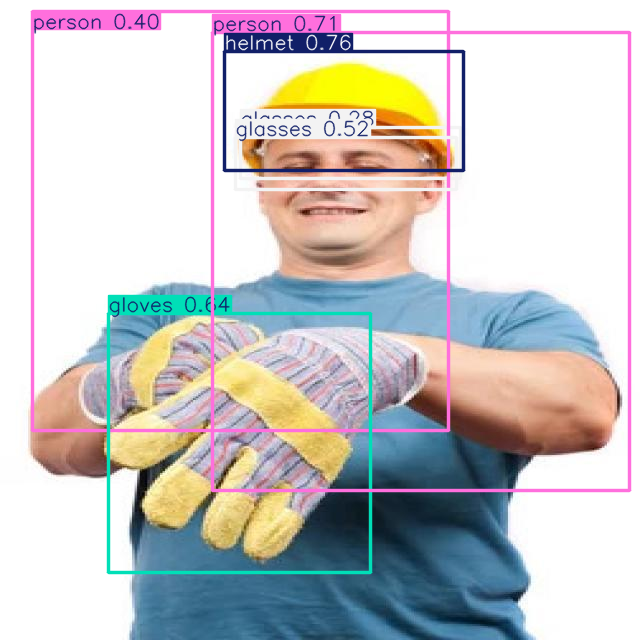


📦 Objetos detectados: 6


In [ ]:
# Predicción en una imagen individual de test
import os
from IPython.display import Image, display

test_images_dir = "/content/dataset/test/images"

# Tomar la primera imagen disponible
test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if test_images:
    sample_image = os.path.join(test_images_dir, test_images[5])
    print(f"🖼️ Probando con: {test_images[0]}")

    results = model.predict(sample_image, save=True, imgsz=640, conf=0.25)

    # Mostrar imagen con predicciones
    results[0].show()
    print(f"\n📦 Objetos detectados: {len(results[0].boxes)}")
else:
    print("⚠️ No se encontraron imágenes en /content/dataset/test/images/")

In [ ]:
# Predicción en TODAS las imágenes de test
import os
from ultralytics import YOLO

test_images_dir = "/content/dataset/test/images"
all_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"🔍 Procesando {len(all_images)} imágenes de test...")
print("-" * 50)

for i, filename in enumerate(all_images):
    image_path = os.path.join(test_images_dir, filename)
    results = model.predict(image_path, save=True, imgsz=640, conf=0.25, verbose=False)
    n_detections = len(results[0].boxes)
    print(f"[{i+1:03d}/{len(all_images)}] {filename:<50} → {n_detections} detecciones")

print("-" * 50)
print("✅ Predicciones completadas. Resultados guardados en /content/runs/")

🔍 Procesando 286 imágenes de test...
--------------------------------------------------
Results saved to /content/runs/detect/predict
[001/286] IMG_6499-e1439982204742_jpg.rf.d59ee3349cea053af9f9dab1730b4319.jpg → 28 detecciones
Results saved to /content/runs/detect/predict
[002/286] images11_jpg.rf.70106d89164a5c1e6dfeeb69b6877cca.jpg → 8 detecciones
Results saved to /content/runs/detect/predict
[003/286] Video4_273_jpg.rf.34a44a8eaa162511f9174c8e693d4457.jpg → 7 detecciones
Results saved to /content/runs/detect/predict
[004/286] ear-muffs-250x250_jpg.rf.6752a472a40265225a04b5e594b18295.jpg → 2 detecciones
Results saved to /content/runs/detect/predict
[005/286] Video1_178_jpg.rf.df898064b51d12ed528627ac7e435829.jpg → 7 detecciones
Results saved to /content/runs/detect/predict
[006/286] 360_F_17642170_G7UD6P6cPCT8JXvPCaooHkfWATfhMTQT_jpg.rf.8350862e8a1e91f12351ddc8f4a44536.jpg → 6 detecciones
Results saved to /content/runs/detect/predict
[007/286] 20220621_132901_jpg.rf.3a9cffc3f9ca94e

In [ ]:
# Descargar el video de ejemplo de GitHub
!wget -O /content/example_video.mp4 https://github.com/adiacla/ppe/raw/main/video/example_video.mp4

--2026-04-23 01:00:26--  https://github.com/adiacla/ppe/raw/main/video/example_video.mp4
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adiacla/ppe/main/video/example_video.mp4 [following]
--2026-04-23 01:00:26--  https://raw.githubusercontent.com/adiacla/ppe/main/video/example_video.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 32903392 (31M) [application/octet-stream]
Saving to: ‘/content/example_video.mp4’

/content/example_vi 100%[===================>]  31.38M  --.-KB/s    in 0.1s    

2026-04-23 01:00:28 (265 MB/s) - ‘/content/example_video.mp4’ saved [32903392/32903392]



In [ ]:
# Predicción en un video
# Reemplazar la ruta con la de tu video descargado.
# Puedes descargarlo y subirlo a /content/ o a Google Drive.

video_source = "/content/example_video.mp4"  # <--- ¡IMPORTANTE! Esta es la ruta del video descargado de GitHub

# Asegúrate de que el modelo esté cargado. Si no has ejecutado las celdas anteriores,
# podrías necesitar ejecutar: model = YOLO("/content/runs/ppe_detector/weights/best.pt")

if os.path.exists(video_source):
    results = model.predict(
        source=video_source,
        conf=0.3,
        save=True,
        project="/content/runs",
        name="video_test"
    )
    print("✅ Predicción en video completada. Resultados guardados en /content/runs/video_test/")
else:
    print(f"⚠️ No se encontró el video en: {video_source}")
    print("Asegúrese de haber descargado el video y que la ruta sea correcta.")

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /content/runs/video_test
✅ Predicción en video completada. Resultados guardados en /content/runs/video_test/


In [ ]:
import os

# Crear carpeta de destino para los modelos exportados
export_dir = "/content/modelos_exportados"
os.makedirs(export_dir, exist_ok=True)
print(f"📁 Carpeta de exportación: {export_dir}")

📁 Carpeta de exportación: /content/modelos_exportados


In [ ]:
# Exportar a ONNX (recomendado para interoperabilidad)
print("⏳ Exportando a ONNX...")
model.export(format="onnx", opset=12)
print("✅ Exportado a ONNX")

⏳ Exportando a ONNX...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/ppe_detector/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 11, 3549) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 284ms
Prepared 4 packages in 9.70s
Installed 4 packages in 477ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.25.0
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 11.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 13.4s

In [ ]:
# Exportar a TorchScript
print("⏳ Exportando a TorchScript...")
model.export(format="torchscript")
print("✅ Exportado a TorchScript")

⏳ Exportando a TorchScript...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/ppe_detector/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 11, 3549) (5.9 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 1.6s, saved as '/content/runs/ppe_detector/weights/best.torchscript' (11.8 MB)

Export complete (1.7s)
Results saved to /content/runs/ppe_detector/weights
Predict:         yolo predict task=detect model=/content/runs/ppe_detector/weights/best.torchscript imgsz=416 
Validate:        yolo val task=detect model=/content/runs/ppe_detector/weights/best.torchscript imgsz=416 data=/content/dataset/data.yaml  
Visualize:       https://netron.app
✅ Exportado a TorchScript


In [ ]:
# Exportar a TensorFlow Lite (para dispositivos móviles)
print("⏳ Exportando a TFLite...")
model.export(format="tflite")
print("✅ Exportado a TensorFlow Lite")

⏳ Exportando a TFLite...
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/ppe_detector/weights/best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) (1, 11, 3549) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 1.33s
Prepared 5 packages in 329ms
Installed 5 packages in 15ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + sng4onnx==2.0.1

requirements: AutoUpdate success ✅ 1.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 1.7s, 